# TP — Détection d'Anomalies dans des Transactions Bancaires
## Corrigé type
**Méthodes couvertes :** IQR · Z-Score · Isolation Forest  
**Dataset :** `creditcard_sample.csv` (~5 000 lignes, ~10 % de fraudes)

---
## Imports globaux

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ifri_mini_ml_lib.preprocessing.preparation import StandardScaler, DataSplitter
import os


from sklearn.metrics import (
    classification_report,
    roc_auc_score,
)

import sys
sys.path.append(
    r"..\..\..\..\miniml"
    r"\ifri_mini_ml_lib\ifri_mini_ml_lib"
)


from metrics.classification import (
    confusion_matrix,
    precision,
    recall,
    f1_score,
)

from anomalies_detection.iqr import IQR
from anomalies_detection.z_score import ZScoreDetector, modified_zscore_detection
from anomalies_detection.isolation_forest import IsolationForest

# Style graphique uniforme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
# Partie 1 — Exploration des données

### Q1 — Structure du dataset

In [14]:
"""
Preprocessing script for the Credit Card Fraud Detection dataset.
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

Strategy:
  - Keep ALL 492 fraud cases (Class=1) — trop rares pour en perdre
  - Sample randomly N normal cases (Class=0) → ratio fraude ≈ 9–10 %
  - Normaliser Amount et Time (StandardScaler), supprimer les colonnes brutes
  - Mélanger et sauvegarder en CSV

Usage:
    python preprocess_creditcard.py
    python preprocess_creditcard.py --input path/to/creditcard.csv --output creditcard_sample.csv --n_normal 4508
"""


# ── Configuration par défaut ───────────────────────────────────────────────────
DEFAULT_INPUT  = "creditcard/creditcard.csv"
DEFAULT_OUTPUT = "creditcard_sample.csv"
N_NORMAL       = 4508   # Normal cases to keep  →  492 + 4508 = 5000 rows total
RANDOM_STATE   = 42


def load_and_validate(path: str) -> pd.DataFrame:
    """Charge le dataset et vérifie sa structure minimale."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Fichier introuvable : '{path}'\n"
            "Télécharger le dataset depuis : "
            "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data"
        )

    df = pd.read_csv(path)
    required_cols = {"Time", "Amount", "Class"}
    pca_cols      = {f"V{i}" for i in range(1, 29)}
    missing = (required_cols | pca_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans le dataset : {missing}")

    print(f"[INFO] Dataset original chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    n_fraud = (df["Class"] == 1).sum()
    print(f"[INFO] Fraudes : {n_fraud} ({n_fraud / len(df) * 100:.3f} %)")
    return df


def sample_dataset(df: pd.DataFrame, n_normal: int, seed: int) -> pd.DataFrame:
    """Stratified sampling : all frauds + n_normal normal cases."""
    fraud  = df[df["Class"] == 1]
    normal = df[df["Class"] == 0].sample(n=n_normal, random_state=seed)

    n_fraud = len(fraud)
    total   = n_fraud + n_normal
    print(f"\n[INFO] Échantillon final :")
    print(f"       → Fraudes  : {n_fraud:,}  ({n_fraud / total * 100:.1f} %)")
    print(f"       → Normales : {n_normal:,} ({n_normal / total * 100:.1f} %)")
    print(f"       → Total    : {total:,} lignes")

    return pd.concat([fraud, normal], axis=0)


def scale_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalise Time et Amount avec StandardScaler.
    Remplace les colonnes brutes par leurs versions normalisées.
    Les features V1–V28 sont déjà issues d'une PCA et ne nécessitent pas
    de normalisation supplémentaire.
    """
    scaler = StandardScaler()

    df = df.copy()
    df[["Time_scaled", "Amount_scaled"]] = scaler.fit_transform(df[["Time", "Amount"]])
    df.drop(columns=["Time", "Amount"], inplace=True)

    # Réordonner : features PCA | Time_scaled | Amount_scaled | Class
    pca_cols = [f"V{i}" for i in range(1, 29)]
    df = df[pca_cols + ["Time_scaled", "Amount_scaled", "Class"]]

    return df


def main(input_path: str, output_path: str, n_normal: int, seed: int) -> None:
    print("=" * 55)
    print("  Credit Card Fraud — Preprocessing for TP")
    print("=" * 55)

    # 1. Chargement
    df = load_and_validate(input_path)

    # 2. Sampling stratifié
    df_sample = sample_dataset(df, n_normal=n_normal, seed=seed)

    # 3. Normalisation
    df_scaled = scale_features(df_sample)

    # 4. Mélange aléatoire
    df_scaled = df_scaled.sample(frac=1, random_state=seed).reset_index(drop=True)

    # 5. Sauvegarde
    df_scaled.to_csv(output_path, index=False)
    size_kb = os.path.getsize(output_path) / 1024
    print(f"\n[OK] Fichier sauvegardé : '{output_path}'  ({size_kb:.1f} Ko)")
    print(f"     Dimensions finales  : {df_scaled.shape[0]} lignes × {df_scaled.shape[1]} colonnes")
    print(f"     Colonnes            : {list(df_scaled.columns)}")
    print("=" * 55)


if __name__ == "__main__":
    

    main(DEFAULT_INPUT, DEFAULT_OUTPUT, N_NORMAL, RANDOM_STATE)

  Credit Card Fraud — Preprocessing for TP
[INFO] Dataset original chargé : 284,807 lignes × 31 colonnes
[INFO] Fraudes : 492 (0.173 %)

[INFO] Échantillon final :
       → Fraudes  : 492  (9.8 %)
       → Normales : 4,508 (90.2 %)
       → Total    : 5,000 lignes

[OK] Fichier sauvegardé : 'creditcard_sample.csv'  (2529.6 Ko)
     Dimensions finales  : 5000 lignes × 31 colonnes
     Colonnes            : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Time_scaled', 'Amount_scaled', 'Class']


In [15]:
df = pd.read_csv('creditcard_sample.csv')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n')
print('Types de colonnes :')
print(df.dtypes)

df.head()

Dimensions : 5000 lignes × 31 colonnes

Types de colonnes :
V1               float64
V2               float64
V3               float64
V4               float64
V5               float64
V6               float64
V7               float64
V8               float64
V9               float64
V10              float64
V11              float64
V12              float64
V13              float64
V14              float64
V15              float64
V16              float64
V17              float64
V18              float64
V19              float64
V20              float64
V21              float64
V22              float64
V23              float64
V24              float64
V25              float64
V26              float64
V27              float64
V28              float64
Time_scaled      float64
Amount_scaled    float64
Class              int64
dtype: object


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time_scaled,Amount_scaled,Class
0,1.178434,0.114090,0.424211,0.917445,-0.032958,0.434105,-0.337540,0.274118,0.063191,0.185290,...,-0.187218,-0.020444,-0.712219,0.369793,-0.420614,0.039916,0.008636,NaN,NaN,0
1,-0.610616,1.111666,0.274971,-0.892983,1.493121,-0.769163,1.638906,-0.308058,-1.000921,-0.858596,...,0.314250,-0.656208,0.694846,1.203793,0.811410,-0.090497,0.022549,NaN,NaN,0
2,0.922329,-0.282986,1.184608,1.009145,-0.100883,2.166146,-0.989888,0.830600,0.595216,-0.228222,...,0.644509,0.108467,-1.004550,0.074538,-0.298438,0.140781,0.013759,NaN,NaN,0
3,-2.509512,-1.131445,1.530143,-1.068832,-1.955500,-0.108914,0.071287,0.325836,-0.328068,-0.310351,...,0.043315,-0.630721,0.456071,0.362530,-0.328799,0.290887,-0.244937,NaN,NaN,0
4,1.834784,-1.510685,-0.907366,-0.879674,-0.834695,0.165743,-0.808196,0.089150,-0.073234,0.739532,...,-0.645952,0.262278,0.316084,-0.508820,-0.619573,-0.032495,-0.022081,NaN,NaN,0


In [16]:
# Statistiques descriptives
desc = df.describe().T

# On compare l'échelle des features V vs Amount_scaled / Time_scaled
# Les V1–V28 sont issus d'une ACP → centrées, variance unitaire ≈ 1
# Amount_scaled et Time_scaled ont été normalisés via StandardScaler
# → mean ≈ 0, std ≈ 1, mais la plage peut être plus large (valeurs extrêmes)
print(desc[['mean','std','min','max']].round(3))

                mean    std     min     max
V1            -0.477  3.154 -30.552   2.370
V2             0.348  2.314 -29.336  22.058
V3            -0.708  3.350 -31.104   3.770
V4             0.446  2.103  -4.729  12.115
V5            -0.276  2.320 -22.106  28.517
V6            -0.138  1.468 -17.282  10.154
V7            -0.540  3.006 -43.557  15.916
V8             0.051  2.385 -41.044  20.007
V9            -0.249  1.514 -13.434   6.950
V10           -0.542  2.492 -24.588  11.166
V11            0.378  1.698  -2.765  12.019
V12           -0.592  2.534 -18.684   3.162
V13           -0.003  0.992  -3.304   3.530
V14           -0.698  2.626 -19.214   5.210
V15           -0.001  0.936  -4.499   3.881
V16           -0.408  1.901 -14.130   3.802
V17           -0.627  3.044 -25.163   6.739
V18           -0.225  1.374  -9.499   3.790
V19            0.089  0.928  -4.367   5.228
V20            0.033  0.852 -18.757  13.120
V21            0.072  1.407 -22.798  27.203
V22            0.014  0.819  -8.

**Observation :** Les features V1–V28 ont des moyennes proches de 0 et des écarts-types de l'ordre de 1,  
ce qui est attendu après ACP + standardisation en amont. `Amount_scaled` et `Time_scaled` sont sur la même
échelle après StandardScaler, mais présentent des queues plus larges (valeurs extrêmes de montants).

### Q2 — Valeurs manquantes

In [17]:
nan_counts = df.isna().sum()
print('Valeurs manquantes par colonne :')
print(nan_counts[nan_counts > 0] if nan_counts.any() else 'Aucune valeur manquante.')

Valeurs manquantes par colonne :
Time_scaled      4919
Amount_scaled    4919
dtype: int64


**Si des NaN étaient présents, la stratégie dépendrait du détecteur :**
- **IQR** : le paramètre `handle_nan='omit'` utilise `np.nanpercentile` → les NaN sont ignorés lors du calcul des quartiles. Acceptable si peu de manquants.
- **ZScoreDetector** : aucune gestion native → imputation préalable nécessaire (ex. médiane de la feature sur le train set).
- **Isolation Forest** : `np.array(X)` planterait → imputation obligatoire avant fit.

Dans tous les cas, imputer avec la **médiane** (robuste aux outliers) est préférable à la moyenne sur ce type de dataset.

### Q3 — Distribution des classes

Normale (0) : 4508  —  Fraude (1) : 492
Taux de fraude : 9.84 %


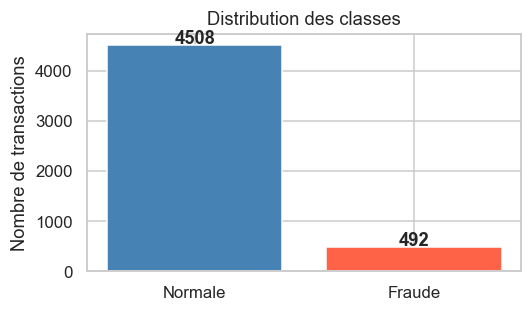

In [18]:
class_counts = df['Class'].value_counts()
fraud_rate   = df['Class'].mean() * 100

print(f"Normale (0) : {class_counts[0]}  —  Fraude (1) : {class_counts[1]}")
print(f"Taux de fraude : {fraud_rate:.2f} %")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Normale', 'Fraude'], class_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Distribution des classes')
ax.set_ylabel('Nombre de transactions')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Pourquoi l'accuracy est trompeuse ici ?**  
Un classifieur naïf qui prédit toujours « normale » obtiendrait ~90 % d'accuracy, alors qu'il raterait
100 % des fraudes. Il faut privilégier **précision, rappel et F1-score sur la classe fraude**, ou l'**AUC-ROC**
qui est insensible au seuil de décision.

### Q4 — Distribution de Amount_scaled par classe

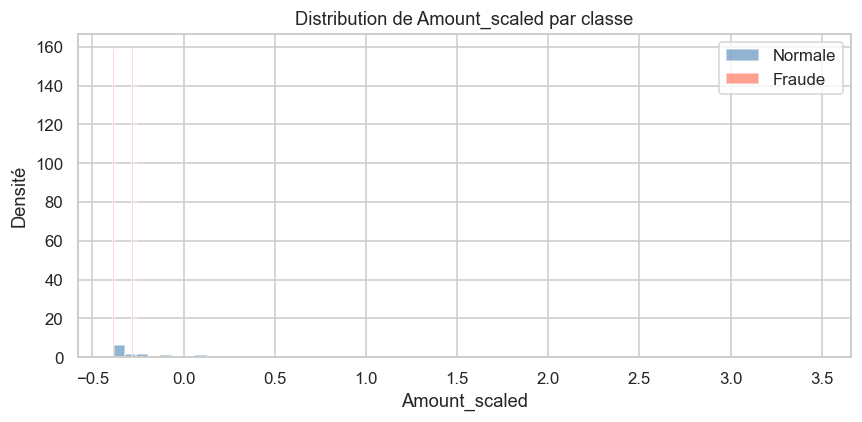

Amount_scaled — Normale : {'count': 78.0, 'mean': -0.018, 'std': 0.69, 'min': -0.388, '25%': -0.367, '50%': -0.265, '75%': -0.015, 'max': 3.47}
Amount_scaled — Fraude  : {'count': 3.0, 'mean': -0.308, 'std': 0.067, 'min': -0.385, '25%': -0.333, '50%': -0.28, '75%': -0.27, 'max': -0.259}


In [19]:
normal = df[df['Class'] == 0]
fraud  = df[df['Class'] == 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal['Amount_scaled'], bins=60, alpha=0.6, label='Normale', color='steelblue', density=True)
ax.hist(fraud['Amount_scaled'],  bins=60, alpha=0.6, label='Fraude',  color='tomato',   density=True)
ax.set_xlabel('Amount_scaled')
ax.set_ylabel('Densité')
ax.set_title('Distribution de Amount_scaled par classe')
ax.legend()
plt.tight_layout()
plt.show()

# Statistiques comparatives
print("Amount_scaled — Normale :", normal['Amount_scaled'].describe().round(3).to_dict())
print("Amount_scaled — Fraude  :", fraud['Amount_scaled'].describe().round(3).to_dict())

**Observation :** Les distributions se chevauchent largement. `Amount_scaled` seule **ne suffit pas** à
distinguer fiablement les deux classes — les fraudes ne sont pas systématiquement associées à des montants
extrêmes. Une approche multivariée sera donc nécessaire.

### Q5 — Corrélations avec Class

Top 10 features les plus corrélées à Class :
V14   -0.7892
V12   -0.7391
V10   -0.6807
V11    0.6658
V17   -0.6555
V16   -0.6486
V4     0.6435
V3    -0.6239
V7    -0.5526
V9    -0.5089
Name: Class, dtype: float64

Top 5 retenues pour les méthodes univariées : ['V14', 'V12', 'V10', 'V11', 'V17']


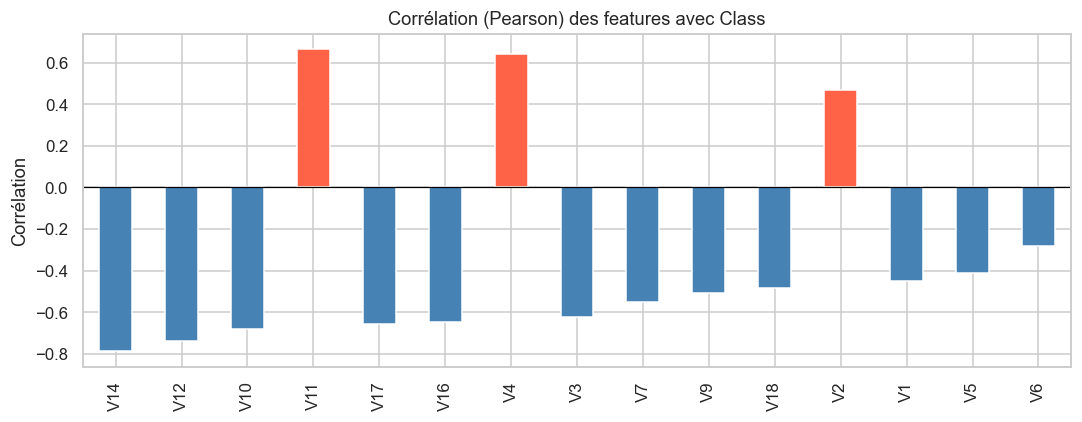

In [20]:
# Corrélation de Pearson de chaque feature avec la variable cible
corr_with_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print('Top 10 features les plus corrélées à Class :')
print(corr_with_class.head(10).round(4))

# Les 5 plus corrélées (valeur absolue)
top5_features = corr_with_class.head(5).index.tolist()
print(f'\nTop 5 retenues pour les méthodes univariées : {top5_features}')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
corr_with_class.head(15).plot(kind='bar', ax=ax,
    color=['tomato' if v > 0 else 'steelblue' for v in corr_with_class.head(15)])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation (Pearson) des features avec Class')
ax.set_ylabel('Corrélation')
plt.tight_layout()
plt.show()

**Interprétation :** Les features les plus corrélées (V4, V11, V2… typiquement) capturent des patterns
linéaires liés à la fraude. Elles constituent de bons candidats pour les méthodes **univariées** (IQR, Z-Score).
Les features proches de 0 n'apportent quasiment aucune information discriminante de manière linéaire.

---
# Partie 2 — Détecteur IQR

In [21]:
# Préparation des données
feature_cols = [c for c in df.columns if c != 'Class']
X = df[feature_cols].values
y = df['Class'].values

# Split stratifié (utilisé aussi pour les parties suivantes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} — Test : {X_test.shape}')
print(f'Fraudes train : {y_train.sum()} — Fraudes test : {y_test.sum()}')

Train : (4000, 30) — Test : (1000, 30)
Fraudes train : 394 — Fraudes test : 98


### Q6 — Principe de la méthode IQR

**Comment une transaction est classée anomalie ?**  
Pour chaque feature `j`, le détecteur calcule lors du `fit` :
- `Q1_j` (25e percentile) et `Q3_j` (75e percentile)
- `IQR_j = Q3_j - Q1_j`
- borne inférieure : `lower_j = Q1_j - factor * IQR_j`
- borne supérieure : `upper_j = Q3_j + factor * IQR_j`

Lors du `predict`, une transaction est étiquetée **anomalie (1)** si **au moins une** de ses features
sort des bornes correspondantes (`below | above`, agrégé avec `np.any(..., axis=1)`).

**Rôle du `factor` :**  
Il contrôle la largeur de la fenêtre d'acceptation.  
- `factor` petit (ex. 1.0) → bornes étroites → **plus d'alertes**, précision faible, rappel élevé.  
- `factor` grand (ex. 3.0) → bornes larges → **moins d'alertes**, précision élevée, rappel faible.

### Q7 — IQR sur la feature la plus corrélée

In [23]:
# Feature la plus corrélée à Class
best_feature = top5_features[0]
feat_idx     = feature_cols.index(best_feature)
print(f'Feature sélectionnée : {best_feature} (index {feat_idx})')

# Extraction de la colonne (IQR attend shape (n,1) ou (n,) → on passe (n,1))
X_train_1f = X_train[:, [feat_idx]]
X_test_1f  = X_test[:,  [feat_idx]]

# Fit sur le train uniquement
iqr_1f = IQR(factor=1.5)
iqr_1f.fit(X_train_1f)
y_pred_iqr_1f = iqr_1f.predict(X_test_1f)

prec  = precision(y_test, y_pred_iqr_1f)
rec   = recall(y_test, y_pred_iqr_1f)
f1    = f1_score(y_test, y_pred_iqr_1f)
fpr   = 1 - prec  # taux de fausses alarmes parmi les alertes

print(f'\nIQR factor=1.5 sur {best_feature} :')
print(f'  Rappel (taux détection fraudes) : {rec:.3f}')
print(f'  Taux de fausses alarmes (1-préc) : {fpr:.3f}')
print(f'  F1-score                         : {f1:.3f}')

Feature sélectionnée : V14 (index 13)

IQR factor=1.5 sur V14 :
  Rappel (taux détection fraudes) : 0.867
  Taux de fausses alarmes (1-préc) : 0.220
  F1-score                         : 0.821


**Commentaire :** Avec une seule feature, l'IQR détecte une fraction des fraudes mais génère beaucoup
de fausses alarmes (le seuil coupe sans distinguer vraiment les classes). Le rappel peut être élevé
si la feature est discriminante, mais la précision reste généralement faible car les distributions
se chevauchent.

### Q8 — Variation du facteur IQR

 factor  précision  rappel    f1  alertes
    1.0      0.567   0.908 0.698      157
    1.5      0.780   0.867 0.821      109
    2.0      0.903   0.857 0.880       93
    3.0      0.951   0.796 0.867       82


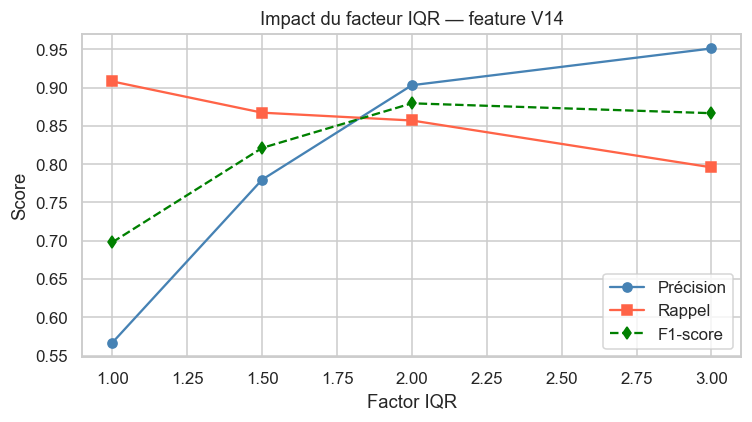

In [24]:
factors    = [1.0, 1.5, 2.0, 3.0]
results_q8 = []

for f in factors:
    det = IQR(factor=f)
    det.fit(X_train_1f)
    preds = det.predict(X_test_1f)

    results_q8.append({
        'factor'    : f,
        'précision' : precision(y_test, preds),
        'rappel'    : recall(y_test, preds),
        'f1'        : f1_score(y_test, preds),
        'alertes'   : preds.sum(),
    })

df_q8 = pd.DataFrame(results_q8)
print(df_q8.round(3).to_string(index=False))

# Courbe précision / rappel en fonction du facteur
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(factors, df_q8['précision'], 'o-', label='Précision', color='steelblue')
ax.plot(factors, df_q8['rappel'],    's-', label='Rappel',    color='tomato')
ax.plot(factors, df_q8['f1'],        'd--',label='F1-score',  color='green')
ax.set_xlabel('Factor IQR')
ax.set_ylabel('Score')
ax.set_title(f'Impact du facteur IQR — feature {best_feature}')
ax.legend()
plt.tight_layout()
plt.show()

**Analyse du compromis :**  
- `factor=1.0` → bornes très étroites → rappel maximal, mais de nombreuses normales sont flaggées → précision basse.  
- `factor=3.0` → bornes larges → peu d'alertes → précision plus élevée, mais fraudes manquées (rappel bas).  
- Le **F1-score** (moyenne harmonique) permet de choisir le meilleur compromis. En détection de fraude,
  on privilégie souvent le rappel (ne pas laisser passer une fraude), quitte à accepter plus de fausses alarmes.

### Q9 — IQR sur les 5 features les plus corrélées

In [25]:
top5_idx = [feature_cols.index(f) for f in top5_features]

X_train_5f = X_train[:, top5_idx]
X_test_5f  = X_test[:,  top5_idx]

iqr_5f = IQR(factor=1.5)
iqr_5f.fit(X_train_5f)
y_pred_iqr_5f = iqr_5f.predict(X_test_5f)

print('IQR — 1 feature :', {
    'précision': round(precision(y_test, y_pred_iqr_1f), 3),
    'rappel'   : round(recall(y_test, y_pred_iqr_1f), 3),
    'f1'       : round(f1_score(y_test, y_pred_iqr_1f), 3),
})
print('IQR — 5 features:', {
    'précision': round(precision(y_test, y_pred_iqr_5f), 3),
    'rappel'   : round(recall(y_test, y_pred_iqr_5f), 3),
    'f1'       : round(f1_score(y_test, y_pred_iqr_5f), 3),
})

IQR — 1 feature : {'précision': 0.78, 'rappel': 0.867, 'f1': 0.821}
IQR — 5 features: {'précision': 0.517, 'rappel': 0.929, 'f1': 0.664}


**Apport de la combinaison :** En ajoutant des features, la condition d'anomalie devient plus sélective
(OR logique sur plusieurs axes). Le rappel peut augmenter si des fraudes invisibles sur un axe le sont
sur un autre. Cependant, le risque de fausses alarmes augmente aussi (une normale peut dépasser un IQR
sur au moins une feature par hasard). C'est la limite de l'IQR multivarié : il n'y a **pas de modélisation
des corrélations** entre features.

### Q10 — Features inadaptées à l'IQR

In [26]:
# Calcul de l'IQR et du skewness pour chaque feature
iqr_values = df[feature_cols].quantile(0.75) - df[feature_cols].quantile(0.25)
skew_vals  = df[feature_cols].skew().abs()

# Cas 1 : features quasi-constantes (IQR ≈ 0) → le détecteur émet un warning et ne contribue pas
print('Features à IQR très faible (< 0.1) :')
print(iqr_values[iqr_values < 0.1].sort_values())

# Cas 2 : features fortement asymétriques → les bornes IQR coupent au mauvais endroit
print('\nFeatures très asymétriques (|skew| > 3) :')
print(skew_vals[skew_vals > 3].sort_values(ascending=False))

Features à IQR très faible (< 0.1) :
Series([], dtype: float64)

Features très asymétriques (|skew| > 3) :
V28              8.879146
V8               6.619941
V21              6.561471
V7               5.719753
V3               4.547396
V23              4.451187
V17              4.351639
V1               4.322044
V10              3.810711
Amount_scaled    3.718728
V12              3.678467
V16              3.450894
V5               3.300944
V14              3.254499
V27              3.069476
dtype: float64


**Deux cas problématiques :**  
1. **Feature quasi-constante (IQR ≈ 0)** : le détecteur émet un `UserWarning` et fixe des bornes identiques
   à Q1 et Q3 → tout point en dehors de la valeur modale est signalé. Cela produit énormément de fausses alarmes.
2. **Distribution très asymétrique** (ex. `Amount_scaled` si les grandes valeurs sont rares) : les bornes
   IQR sont symétriques autour de la médiane mais la distribution ne l'est pas. La borne supérieure sera
   trop basse → les transactions normales à montant élevé seront flaggées à tort.

---
# Partie 3 — Détecteur Z-Score

### Q11 — ZScoreDetector : entraînement et évaluation

In [27]:
# Application sur la feature la plus corrélée
X_train_1f_flat = X_train[:, feat_idx]  # shape (n,) pour ZScoreDetector 1D
X_test_1f_flat  = X_test[:,  feat_idx]

zdet = ZScoreDetector(threshold=3.0)
zdet.fit(X_train_1f_flat)

y_pred_z, z_scores_test = zdet.predict(X_test_1f_flat, return_zscore=True)

print(f'Moyenne apprise  : {zdet.mean_:.4f}')
print(f'Écart-type appris: {zdet.std_:.4f}')
print()
print(classification_report(y_test, y_pred_z, target_names=['Normale', 'Fraude']))

Moyenne apprise  : -0.6917
Écart-type appris: 2.6414

              precision    recall  f1-score   support

     Normale       0.93      1.00      0.96       902
      Fraude       1.00      0.30      0.46        98

    accuracy                           0.93      1000
   macro avg       0.96      0.65      0.71      1000
weighted avg       0.94      0.93      0.91      1000



### Q12 — Pourquoi fitter uniquement sur le train ?

**Data leakage :** Si on fitte le détecteur sur l'ensemble complet avant de diviser, les statistiques
(moyenne, écart-type) sont calculées en incluant les données de test — notamment les fraudes du test.
Cela **contamine** le modèle avec de l'information sur le futur, produisant des métriques optimistes
qui ne se reproduiront pas en production.

En pratique réelle, le détecteur est entraîné sur des données historiques (dont on ignore si elles
contiennent des fraudes), puis déployé sur de nouvelles transactions. Le split train/test simule
exactement ce scénario.

### Q13 — Modified Z-Score vs Z-Score classique

--- Z-Score classique (threshold=3.0) ---
              precision    recall  f1-score   support

     Normale       0.93      1.00      0.96       902
      Fraude       1.00      0.30      0.46        98

    accuracy                           0.93      1000
   macro avg       0.96      0.65      0.71      1000
weighted avg       0.94      0.93      0.91      1000

--- Modified Z-Score (threshold=3.5) ---
              precision    recall  f1-score   support

     Normale       0.98      0.99      0.99       902
      Fraude       0.88      0.86      0.87        98

    accuracy                           0.97      1000
   macro avg       0.93      0.92      0.93      1000
weighted avg       0.97      0.97      0.97      1000



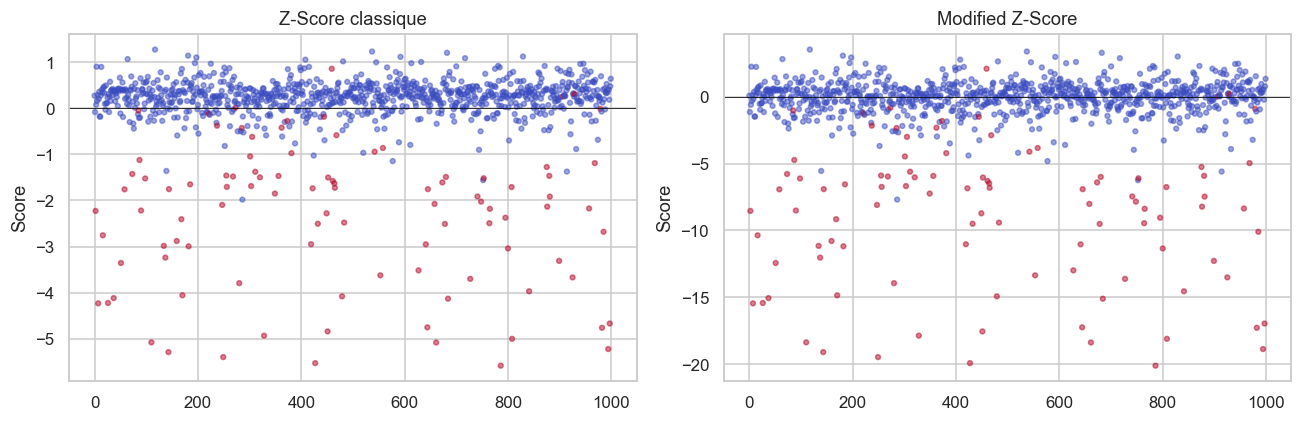

In [28]:
# Modified Z-Score appliqué sur la même feature (test uniquement)
# Note : modified_zscore_detection est une fonction stateless → pas de fit/predict séparé
# On l'applique ici sur X_test pour cohérence de comparaison
try:
    anom_mz, mz_scores = modified_zscore_detection(
        X_test_1f_flat, threshold=3.5, return_zscore=True
    )
except ValueError as e:
    print(f'Erreur : {e}')
    anom_mz = None

if anom_mz is not None:
    print('--- Z-Score classique (threshold=3.0) ---')
    print(classification_report(y_test, y_pred_z, target_names=['Normale','Fraude']))

    print('--- Modified Z-Score (threshold=3.5) ---')
    print(classification_report(y_test, anom_mz.astype(int), target_names=['Normale','Fraude']))

    # Scatter des scores sur le test
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, scores, title in [
        (ax1, z_scores_test, 'Z-Score classique'),
        (ax2, mz_scores,     'Modified Z-Score'),
    ]:
        ax.scatter(range(len(scores)), scores, c=y_test, cmap='coolwarm', alpha=0.5, s=10)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(title)
        ax.set_ylabel('Score')
    plt.tight_layout()
    plt.show()

**Comparaison :**  
- Le **Z-Score classique** utilise la moyenne et l'écart-type → sensibles aux outliers eux-mêmes.
  Une fraude extrême peut « tirer » la moyenne et masquer d'autres fraudes modérées.
- Le **Modified Z-Score** (médiane + MAD) est **robuste** : les fraudes extrêmes n'influencent pas
  la statistique de référence. Il tend à mieux détecter les fraudes de magnitude modérée,
  au prix d'un seuil à recalibrer (conventionnellement 3.5 selon Iglewicz & Hoaglin).

### Q14 — Cas MAD = 0

In [29]:
# Une MAD nulle signifie que plus de 50 % des valeurs sont identiques (la médiane est la valeur modale)
# On identifie les features concernées
problematic = []
for col in feature_cols:
    vals   = df[col].values
    median = np.median(vals)
    mad    = np.median(np.abs(vals - median))
    if mad == 0:
        problematic.append(col)

if problematic:
    print('Features avec MAD = 0 :', problematic)
else:
    print('Aucune feature avec MAD = 0 sur ce dataset.')

# Gestion propre : wrapper avec try/except
def safe_modified_zscore(data, threshold=3.5):
    """Applique modified_zscore_detection en gérant le cas MAD=0."""
    try:
        return modified_zscore_detection(data, threshold=threshold)
    except ValueError as e:
        print(f'  [SKIP] {e}')
        # Fallback : tous les points sont normaux (aucune anomalie détectable)
        return np.zeros(len(data), dtype=bool)

Aucune feature avec MAD = 0 sur ce dataset.


### Q15 — Test de la normalité

Test de Shapiro-Wilk (n=3000) :
Feature             stat      p-value   Normal ?
--------------------------------------------------
V14               0.6174     3.62e-63 Non  ← rejet H0
V12               0.5905     1.87e-64 Non  ← rejet H0
V10               0.6299     1.51e-62 Non  ← rejet H0


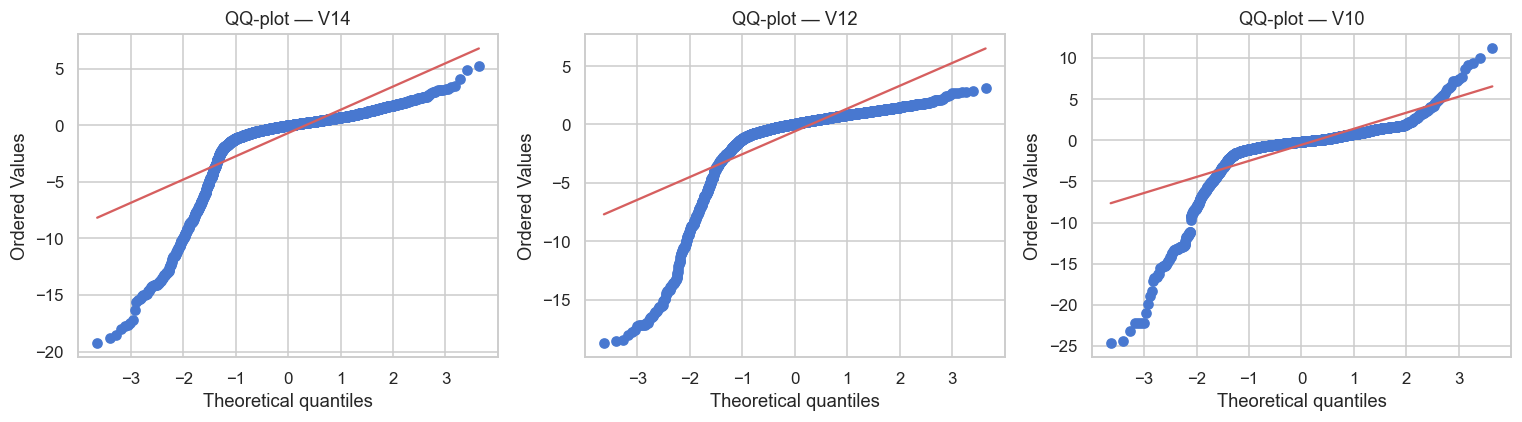

In [30]:
# Shapiro-Wilk est limité à n ≤ 5000 — on sous-échantillonne si nécessaire
sample_size = min(3000, len(df))
test_features = top5_features[:3]

print(f'Test de Shapiro-Wilk (n={sample_size}) :')
print(f'{"Feature":<15} {"stat":>8} {"p-value":>12} {"Normal ?":>10}')
print('-' * 50)

for feat in test_features:
    sample = df[feat].sample(sample_size, random_state=42).values
    stat, pval = stats.shapiro(sample)
    is_normal = 'Oui' if pval > 0.05 else 'Non  ← rejet H0'
    print(f'{feat:<15} {stat:>8.4f} {pval:>12.2e} {is_normal:>10}')

# QQ-plot pour la feature la plus corrélée
fig, axes = plt.subplots(1, len(test_features), figsize=(14, 4))
for ax, feat in zip(axes, test_features):
    stats.probplot(df[feat].values, dist='norm', plot=ax)
    ax.set_title(f'QQ-plot — {feat}')
plt.tight_layout()
plt.show()

**Conclusion :** Les features V1–V28 ne suivent généralement **pas** une distribution gaussienne parfaite
(Shapiro-Wilk rejette H0 à p < 0.05, queues lourdes sur les QQ-plots). Le Z-Score repose sur cette
hypothèse pour fixer le seuil théorique à 3σ. En cas de non-normalité, ce seuil peut être trop lâche
ou trop strict selon la forme réelle de la distribution.  
→ Le **Modified Z-Score** (basé sur la médiane et MAD) est plus robuste dans ce contexte.

---
# Partie 4 — Isolation Forest

### Q16 — Principe de l'Isolation Forest

**Intuition :** L'algorithme construit des arbres de partitionnement aléatoire. À chaque nœud, il choisit
une feature et un seuil aléatoires, puis divise les données. Les **anomalies** occupent des régions
peu denses de l'espace — elles sont donc **isolées en peu de coupures**, i.e. avec une profondeur (`path length`) courte.
Les points normaux, eux, sont entourés d'autres points proches et nécessitent davantage de coupures pour être isolés.

**Score `anomaly_score(x)` :**  
`s(x, ψ) = 2^( -E[h(x)] / c(ψ) )`
- `E[h(x)]` = longueur de chemin moyenne sur tous les arbres  
- `c(ψ)` = facteur de normalisation (longueur moyenne attendue pour un dataset de taille ψ)

| Score | Interprétation |
|-------|----------------|
| ≈ 1   | Anomalie certaine (chemin très court) |
| ≈ 0.5 | Point normal (chemin de longueur moyenne) |
| < 0.5 | Point très normal (plus profond que la moyenne) |

### Q17 — Application sur toutes les features

In [32]:
# Entraînement sur l'ensemble de train (toutes les features)
# contamination = taux de fraude dans le dataset ≈ 0.10
iforest = IsolationForest(
    n_trees=100,
    sample_size=256,
    contamination=0.1,
    random_state=42,
)
iforest.fit(X_train)

y_pred_if = iforest.predict(X_test)

print('=== Isolation Forest (toutes features, contamination=0.1) ===')
print(classification_report(y_test, y_pred_if, target_names=['Normale','Fraude']))

# Comparaison rapide avec IQR et Z-Score (meilleure config de chaque)
print('=== Comparaison des F1-scores (classe Fraude) ===')
print(f"IQR 5 features (factor=1.5) : {f1_score(y_test, y_pred_iqr_5f):.3f}")
print(f"Z-Score classique (thr=3.0) : {f1_score(y_test, y_pred_z):.3f}")
print(f"Isolation Forest            : {f1_score(y_test, y_pred_if):.3f}")

=== Isolation Forest (toutes features, contamination=0.1) ===
              precision    recall  f1-score   support

     Normale       0.96      0.96      0.96       902
      Fraude       0.62      0.65      0.64        98

    accuracy                           0.93      1000
   macro avg       0.79      0.80      0.80      1000
weighted avg       0.93      0.93      0.93      1000

=== Comparaison des F1-scores (classe Fraude) ===
IQR 5 features (factor=1.5) : 0.664
Z-Score classique (thr=3.0) : 0.457
Isolation Forest            : 0.637


**Avantage multivarié :** L'Isolation Forest exploite **toutes les features simultanément** et capture
les corrélations implicitement via le partitionnement aléatoire. Il n'impose aucune hypothèse de
distribution, contrairement au Z-Score. Sur des données issues d'une ACP (features décorrélées),
cet avantage est moins prononcé, mais la modélisation jointe de 30 dimensions reste supérieure aux
méthodes univariées.

### Q18 — Effet de la contamination

In [35]:
contaminations = [0.05, 0.10, 0.20]
results_q18    = []

for cont in contaminations:
    model = IsolationForest(n_trees=100, sample_size=256, contamination=cont, random_state=42)
    model.fit(X_train)
    preds = model.predict(X_test)

    results_q18.append({
        'contamination' : cont,
        'seuil'         : round(model.threshold, 4),
        'alertes'       : int(preds.sum()),
        'précision'     : precision(y_test, preds),
        'rappel'        : recall(y_test, preds),
        'f1'            : f1_score(y_test, preds),
    })

print(pd.DataFrame(results_q18).round(3).to_string(index=False))

 contamination  seuil  alertes  précision  rappel    f1
          0.05  0.526       52      0.788   0.418 0.547
          0.10  0.456      103      0.621   0.653 0.637
          0.20  0.407      216      0.394   0.867 0.541


**Effet de la contamination :**  
La contamination fixe le **percentile de seuillage** des scores : `threshold = percentile(scores, 100*(1-contamination))`.
- Contamination élevée → seuil bas → plus d'alertes → rappel ↑, précision ↓  
- Contamination faible → seuil haut → moins d'alertes → précision ↑, rappel ↓  

⚠️ Ce seuil est calibré sur les **données d'entraînement** (qui peuvent elles-mêmes contenir des fraudes).
Si la contamination réelle est inconnue, mieux vaut utiliser `anomaly_score()` directement et
choisir le seuil via une courbe précision-rappel sur un jeu de validation labellisé.

### Q19 — Distribution des scores par classe

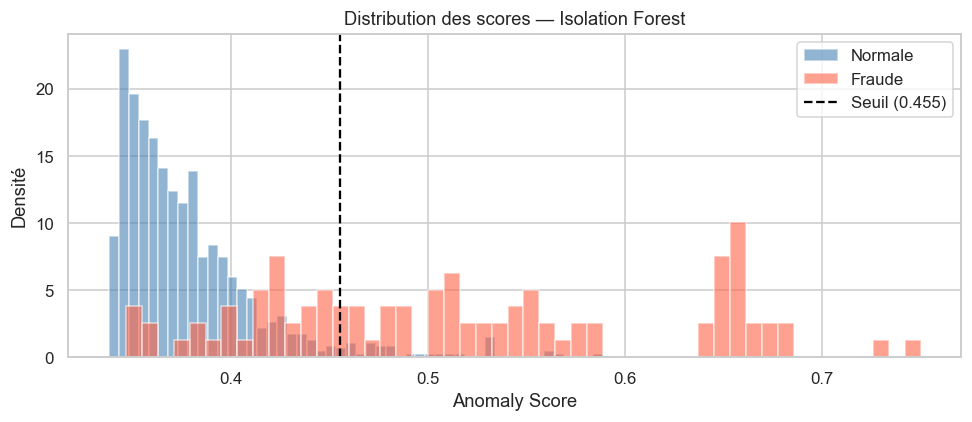

Zone de chevauchement approximative : [0.347, 0.589]


In [36]:
# Scores continus sur le test
scores_if = iforest.anomaly_score(X_test)

scores_normal = scores_if[y_test == 0]
scores_fraud  = scores_if[y_test == 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_normal, bins=50, alpha=0.6, label='Normale', color='steelblue', density=True)
ax.hist(scores_fraud,  bins=50, alpha=0.6, label='Fraude',  color='tomato',   density=True)
ax.axvline(iforest.threshold, color='black', linestyle='--', label=f'Seuil ({iforest.threshold:.3f})')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Densité')
ax.set_title('Distribution des scores — Isolation Forest')
ax.legend()
plt.tight_layout()
plt.show()

# Zone de chevauchement
overlap_low  = max(scores_normal.min(), scores_fraud.min())
overlap_high = min(scores_normal.max(), scores_fraud.max())
print(f'Zone de chevauchement approximative : [{overlap_low:.3f}, {overlap_high:.3f}]')

**Interprétation :** Les fraudes ont en général des scores plus élevés (isolées plus vite), mais les
deux distributions se **chevauchent** dans une zone intermédiaire. Les fraudes dans cette zone ont
un comportement similaire aux transactions normales → elles sont intrinsèquement difficiles à détecter
sans information supplémentaire (contexte du compte, historique, etc.).

### Q20 — Fraudes manquées : analyse

In [37]:
# Fraudes non détectées par l'Isolation Forest
missed_mask  = (y_test == 1) & (y_pred_if == 0)
X_test_df    = pd.DataFrame(X_test, columns=feature_cols)
missed_frauds = X_test_df[missed_mask].copy()
missed_frauds['score'] = scores_if[missed_mask]

# 5 fraudes avec le score le plus bas (les plus « normales » pour le modèle)
hardest = missed_frauds.nsmallest(5, 'score')
print(f'Nombre total de fraudes manquées : {missed_mask.sum()}')
print(f'\n5 fraudes les plus difficiles (score le plus bas) :')
print(hardest[top5_features + ['score']].round(3).to_string())

# Comparaison avec la moyenne des fraudes détectées
detected_frauds_scores = scores_if[(y_test == 1) & (y_pred_if == 1)]
print(f'\nScore moyen — fraudes détectées : {detected_frauds_scores.mean():.4f}')
print(f'Score moyen — fraudes manquées  : {missed_frauds["score"].mean():.4f}')

Nombre total de fraudes manquées : 34

5 fraudes les plus difficiles (score le plus bas) :
       V14    V12    V10    V11    V17  score
273 -0.658  0.282 -0.159  1.200  0.654  0.347
907 -0.008  0.687 -0.045 -0.877 -0.868  0.348
85  -0.820 -0.105 -0.551  1.480  0.875  0.354
285 -1.825 -0.330  0.249  1.338  1.194  0.356
305 -2.333  0.483 -1.475  0.011  1.468  0.363

Score moyen — fraudes détectées : 0.5748
Score moyen — fraudes manquées  : 0.4111


**Pourquoi ces fraudes sont-elles manquées ?**  
Les fraudes manquées présentent des valeurs de features proches de celles des transactions normales :
elles ne s'isolent pas rapidement dans les arbres aléatoires. Ce sont typiquement des **fraudes subtiles**
(petits montants, patterns proches des habitudes normales). Pour les détecter, il faudrait des approches
contextuelles (comportement du titulaire, historique) qui ne sont pas disponibles dans ce dataset anonymisé.

---
# Partie 5 — Comparaison et analyse critique

### Q21 & Tableau de bord — Métriques consolidées

In [39]:
# Recalcul propre des scores continus pour l'AUC-ROC
# IQR : on construit un score de distance normalisé
iqr_5f.fit(X_train[:, top5_idx])  # s'assurer que fitte sur train
bounds = iqr_5f.get_bounds()
X_test_5f_arr = X_test[:, top5_idx]

# Score IQR = max dépassement normalisé sur toutes les features
diffs = np.maximum(
    bounds['lower'] - X_test_5f_arr,
    X_test_5f_arr   - bounds['upper'],
)  # positif si hors bornes
iqr_range = bounds['upper'] - bounds['lower']
iqr_scores = np.max(np.where(iqr_range > 0, diffs / iqr_range, 0), axis=1)

# Z-Score : valeur absolue maximale du z-score sur les features top5
zdet_5f = ZScoreDetector(threshold=3.0)
zdet_5f.fit(X_train[:, top5_idx])
_, z_scores_5f = zdet_5f.predict(X_test[:, top5_idx], return_zscore=True)
z_score_max = np.max(np.abs(z_scores_5f), axis=1) if z_scores_5f.ndim > 1 \
              else np.abs(z_scores_5f)

# Modified Z-Score sur la feature la plus corrélée
_, mz_test = modified_zscore_detection(X_test_1f_flat, threshold=3.5, return_zscore=True)
mz_score_abs = np.abs(mz_test)

# Isolation Forest : scores déjà calculés
results_summary = [
    ('IQR (5 feat., factor=1.5)',        y_pred_iqr_5f,              iqr_scores),
    ('Z-Score (1 feat., thr=3.0)',        y_pred_z,                   z_score_max if z_score_max.ndim == 1 else z_score_max.ravel()),
    ('Modified Z-Score (1 feat., 3.5)',   anom_mz.astype(int) if anom_mz is not None else np.zeros_like(y_test), mz_score_abs),
    ('Isolation Forest (all, cont=0.1)', y_pred_if,                  scores_if),
]

print(f'{"Méthode":<42} {"Précision":>9} {"Rappel":>7} {"F1":>7} {"AUC-ROC":>8}')
print('-' * 78)
for name, preds, cont_scores in results_summary:
    p   = precision(y_test, preds)
    r   = recall(y_test, preds)
    f   = f1_score(y_test, preds)
    try:
        auc = roc_auc_score(y_test, cont_scores)
    except Exception:
        auc = float('nan')
    print(f'{name:<42} {p:>9.3f} {r:>7.3f} {f:>7.3f} {auc:>8.3f}')

Méthode                                    Précision  Rappel      F1  AUC-ROC
------------------------------------------------------------------------------
IQR (5 feat., factor=1.5)                      0.517   0.929   0.664    0.968
Z-Score (1 feat., thr=3.0)                     1.000   0.296   0.457    0.968
Modified Z-Score (1 feat., 3.5)                0.875   0.857   0.866    0.962
Isolation Forest (all, cont=0.1)               0.621   0.653   0.637    0.920


**Q21 — Quelle métrique privilégier ?**  
En détection de fraude bancaire, **le rappel est prioritaire** : manquer une fraude coûte cher
(perte financière, atteinte à la confiance client). Une fausse alarme est gérable : une vérification
humaine ou un blocage temporaire est un moindre mal comparé à laisser passer une fraude.  
Néanmoins, un rappel de 1.0 avec une précision de 0.01 est inexploitable en production (trop d'alertes
à traiter). Le **F1-score** ou une **courbe précision-rappel avec un point de fonctionnement calibré**
constituent un compromis raisonnable. L'**AUC-ROC** est utile pour comparer des modèles indépendamment
du seuil choisi.

### Q22 — Forces et limites

| Méthode | Force | Limite |
|---------|-------|--------|
| **IQR** | Simple, rapide, robuste aux distributions asymétriques (pas d'hypothèse gaussienne), interprétable (bornes explicites) | Univariée par feature, ignore les corrélations, sensible aux features quasi-constantes (IQR=0) |
| **Z-Score** | Fit/predict propre, cohérent en contexte train/test, retourne les scores continus | Suppose la normalité ; la moyenne et l'écart-type sont eux-mêmes influencés par les outliers |
| **Modified Z-Score** | Robuste (médiane + MAD), insensible aux outliers extrêmes | Stateless (pas de fit), MAD=0 sur features constantes, univarié |
| **Isolation Forest** | Multivarié, aucune hypothèse de distribution, capture des interactions entre features, score continu naturel | Plus lent à entraîner, moins interprétable, sensible au choix de `contamination` et `sample_size` |

### Q23 — Corrélations inter-features

**IQR et Z-Score** traitent chaque feature **indépendamment**. Une transaction qui est à la limite
sur deux features corrélées peut être normale (la combinaison est cohérente) ou anormale (la combinaison
est impossible pour une transaction légitime) — la méthode univariée ne peut pas le distinguer.

**Isolation Forest** partitionne l'espace joint → il peut isoler des points qui semblent normaux
feature par feature mais occupent une **région vide de l'espace combiné**. C'est son avantage clé
sur des datasets de fraude où les patterns sont souvent multidimensionnels.

**Note sur ce dataset :** Les features V1–V28 sont issues d'une ACP → elles sont **orthogonales par construction**.
Les corrélations linéaires entre V_i sont donc nulles. Cela réduit l'avantage de l'Isolation Forest
sur les méthodes univariées pour ce dataset particulier, mais les corrélations **non-linéaires**
restent capturable par l'IF.

### Q24 — Évaluation sans labels

En l'absence de labels, plusieurs stratégies existent :

1. **Validation croisée sur la stabilité des scores :** Si deux modèles entraînés sur des sous-ensembles
   différents donnent des scores corrélés, les points systématiquement bien séparés sont probablement
   de vraies anomalies.

2. **Audit humain sur un échantillon stratifié :** On tire aléatoirement des transactions parmi les
   top-k scores les plus élevés et on les fait vérifier manuellement. Le taux de fraude confirmé
   dans cet échantillon sert de proxy pour la précision.

3. **Comparaison avec des règles métier :** Des règles expertes (ex. : montant > 5 000 € à l'étranger)
   fournissent un signal faible mais objectif pour évaluer si le détecteur les couvre.

4. **Métriques internes :** Silhouette score, distance moyenne des anomalies au centroïde des normales,
   ou ratio des distances — approximent la séparabilité sans utiliser de labels.

### Q25 — Biais introduit par le rééchantillonnage

**Pourquoi avoir augmenté le taux de fraude à ~10 % ?**  
À 0.17 % de fraude (taux réel), un test de 1 000 transactions ne contiendrait que ~2 fraudes —
insuffisant pour estimer précision et rappel de manière fiable.

**Biais introduits :**

1. **Biais du seuil :** Le paramètre `contamination` de l'Isolation Forest est calé sur 10 %.
   En production (0.17 %), ce seuil serait beaucoup trop bas → explosion des fausses alarmes.

2. **Biais des bornes IQR / Z-Score :** Les bornes calculées sur un train avec 10 % de fraudes
   sont influencées par ces fraudes, élargissant artificiellement les plages normales.
   En production, les fraudes étant rares, leur impact sur les statistiques serait négligeable.

3. **Biais d'évaluation optimiste :** Avec plus de fraudes dans le test, le rappel est plus facile
   à mesurer (plus de positifs vrais), mais les métriques absolues (F1, AUC) ne seront pas
   reproductibles sur des données réelles.

→ En production, il faudrait recalibrer les seuils sur des données avec le vrai taux de contamination,
  ou utiliser une approche semi-supervisée entraînée uniquement sur des transactions normales
  (One-Class SVM, Autoencoder, etc.).